In [ ]:
# ============================================================================
# CELL 1: Install dependencies
# ============================================================================
#@title Install dependencies
#@markdown This installs RDKit and required packages (takes a few sec)

import os
import sys
from IPython.display import Image, display

# Use the raw content URL
url = "https://raw.githubusercontent.com/AzizAbusaleh/PCCL/main/pccl_rxns_a1-a8.png"


print("Installing RDKit...")
!pip install -q rdkit pandas requests

print("✓ Installation complete!")
# Display the image
display(Image(url=url))



Installing RDKit...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 21.9 MB/s eta 0:00:00
✓ Installation complete!


In [ ]:
# ============================================================================
# CELL 2: Load reagent libraries directly from GitHub
# ============================================================================
#@title Load reagent libraries directly from GitHub
#@markdown Select the lab and reaction to work with

import os
import requests
import pickle
import gzip
import io
import re
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdFingerprintGenerator

# Initialize Morgan fingerprint generator
MORGAN_GEN = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

# GitHub repository base URL
GITHUB_BASE = "https://raw.githubusercontent.com/AzizAbusaleh/PCCL/main/"

# Updated Lab and reaction mapping with number of reagents
REACTION_INFO = {
    "Rousseaux": {
        "a1": {
            "type": "conditional",
            "num_reagents": {"a1_1": 2, "a1_2": 3},
            "smarts": {
                "a1_1": "[OH]-[CH2:4]-[CH2:2]-[#6:1].[NX3H1:6]-[#6:7]>>[CD2]1-[CD3:2]([#6:1])-[CX4:4]1-[NX3;!$(NC=O):6]-[#6:7]",
                "a1_2": "[Br]-[CX4:4]-[CX4:2]-[#6:1].[CX4]-O-[CX3:3](=O)-[CX4:5].[NX3H1:6]-[#6:7]>>[CD2:3]1-[CD3:2]([#6:1])-[CX4:4]1([CX4:5])-[NX3;!$(NC=O):6]-[#6:7]"
            },
            "files": {
                "reagents": {
                    "a1_1": ["R1_A_group1_fingerprints.pkl.gz", "R1_C_group1_fingerprints.pkl.gz"],
                    "a1_2": ["R1_A_group1_fingerprints.pkl.gz", "R1_B_group1_fingerprints.pkl.gz", "R1_C_group1_fingerprints.pkl.gz"]
                }
            }
        }
    },
    "Le": {
        "a2": {
            "type": "single",
            "num_reagents": 1,
            "smarts": "[#6:1][NH:2][#6:3]>>[#6:1][N:2]([#6:3])[C:4](=[O:5])[F:6]",
            "files": ["R1_A_group1_fingerprints.pkl.gz"]
        }
    },
    "Beauchemin": {
        "a3": {
            "type": "two_reagents",
            "num_reagents": 2,
            "smarts": "[#6:3]-[CX2H0:2]#[CX2H0:1]-[CX4H2:7]-[#6:8].[#6:9]-[NH2:10]>>[ND3:10]1(-[#6:9])-[CD3H0:1](=[CD2H1:7]-[#6:8])-[CD3:2](-[#6:3])=[ND2]-[ND2H1]-[CD3]-1=[O]",
            "files": ["R1_A_group1_fingerprints.pkl.gz", "R1_B_group1_fingerprints.pkl.gz"]
        },
        "a4": {
            "type": "dual_smarts",
            "num_reagents": 2,
            "smarts": {
                "hydrazine": "O=[C:2]([#6:3])-[CH2;!R:1]-Br.[N:9]-[NH2:10]>>[ND3:10]1(-[N:9])-[CD2H2:1]-[CD3:2](-[#6:3])=[ND2]-[ND2H1]-[CD3]-1=[O]",
                "primary_amine": "O=[C:2]([#6:3])-[CH2;!R:1]-Br.[#6:9]-[NH2:10]>>[ND3:10]1(-[#6:9])-[CD2H2:1]-[CD3:2](-[#6:3])=[ND2]-[ND2H1]-[CD3]-1=[O]"
            },
            "files": ["R1_A_group1_fingerprints.pkl.gz", "R1_B_group1_fingerprints.pkl.gz"]
        }
    },
    "Lundgren": {
        "a5": {
            "type": "dual_smarts",
            "num_reagents": 2,
            "smarts": {
                "alcohol": "[a:1][CH2:2]C(=O)[OH].[#6:4][CX3H:5]=[CX3H:6][CX4H2:7][OH]>>[a:1][CX4H2:2][CX4H1:5]([#6:4])[CX3H1:6]=[CX3H2:7]",
                "ester": "[a:1][CH2:2]C(=O)[OH].[#6:4][CX3H:5]=[CX3H:6][CX3:7](=O)[O][#6]>>[a:1][CX4H2:2][CX4H1:5]([#6:4])[CX3H1:6]=[CX3H2:7]"
            },
            "files": ["R1_A_group1_fingerprints.pkl.gz", "R1_B_group1_fingerprints.pkl.gz"]
        },
        "a6": {
            "type": "single",
            "num_reagents": 1,
            "smarts": "[a:1][CH2:2]C(=O)[OH]>>[a:1][CH2:2][C]1C=CCCC1",
            "files": ["R1_A_group1_fingerprints.pkl.gz"]
        },
        "a7": {
            "type": "two_reagents",
            "num_reagents": 2,
            "smarts": "[*:1][CX2H0:2]#[CX2H1:3].[CX2H1:4]#[CX2H0:5][CX3H0:6](=[O:7])[*:8]>>[*:1][CX3H1:2]=[CH:3][CH:4]=[CH:5][CX3H0:6](=[O:7])[*:8]",
            "files": ["R1_A_group1_fingerprints.pkl.gz", "R1_B_group1_fingerprints.pkl.gz"]
        },
        "a8": {
            "type": "three_reagents",
            "num_reagents": 3,
            "smarts": "[*:1][CX2H0:2]#[CX2H1:3].[CX2H1:4]#[CX2H0:5][CX3H0:6](=[O:7])[*:8].[c:11][B]([OH])[OH]>>[*:1][CX3H1:2]=[CH:3][CH:4]([c:11])[CH2:5][CX3H0:6](=[O:7])[*:8]",
            "files": ["R1_A_group1_fingerprints.pkl.gz", "R1_B_group1_fingerprints.pkl.gz", "R1_C_group1_fingerprints.pkl.gz"]
        }
    }
}

#@markdown ### Select Lab and Reaction
lab = "Lundgren"  #@param ["Rousseaux", "Le", "Beauchemin", "Lundgren"]
reaction = "a5"  #@param ["a1", "a2", "a3", "a4", "a5", "a6", "a7", "a8"]

# Validate selection
if lab not in REACTION_INFO:
    print(f"Error: Lab {lab} not found in available labs")
    sys.exit(1)

if reaction not in REACTION_INFO[lab]:
    print(f"Error: Reaction {reaction} not available for lab {lab}")
    sys.exit(1)

# Get reaction info
reaction_info = REACTION_INFO[lab][reaction]
reaction_type = reaction_info["type"]

# Define base path
base_path = f"fp/{lab}/{reaction}"

# Function to load data directly from GitHub
def load_from_github(github_path):
    """Load file content directly from GitHub"""
    url = GITHUB_BASE + github_path
    try:
        response = requests.get(url)
        response.raise_for_status()
        return response.content
    except Exception as e:
        print(f"Error loading {github_path}: {e}")
        return None

# Function to load fingerprints directly from GitHub
def load_fingerprints_from_github(github_path):
    """Load fingerprint pickle file directly from GitHub"""
    content = load_from_github(github_path)
    if content is None:
        return []

    try:
        # For gzipped pickle files
        with gzip.open(io.BytesIO(content), 'rb') as f:
            fingerprints = pickle.load(f)
        print(f"  ✓ Loaded {len(fingerprints)} fingerprints from {os.path.basename(github_path)}")
        return fingerprints
    except Exception as e:
        print(f"Error unpacking fingerprints: {e}")
        return []

# Function to load building block data and create complete reagent libraries (no price)
def load_complete_reagent_data(fingerprints_list, reagent_type, reagent_idx):
    """Convert fingerprint list to complete reagent library with molecules (ignores price)"""
    reagents = []

    for idx, fp_data in enumerate(fingerprints_list):
        # Handle different possible data structures
        if isinstance(fp_data, dict):
            # Use provided id and smiles
            reagent_id = fp_data.get('id', f"{reagent_type}_{reagent_idx}_{idx}")
            smiles = fp_data.get('smiles', '')
            fp = fp_data.get('fp')
        else:
            # If it's just the fingerprint object, create placeholder
            reagent_id = f"{reagent_type}_{reagent_idx}_{idx}"
            smiles = f"CCCC{idx}"
            fp = fp_data

        # Try to create molecule from SMILES
        mol = Chem.MolFromSmiles(smiles) if smiles else None

        if mol is None:
            # If we can't create molecule, skip this entry
            continue

        reagents.append({
            'smiles': smiles,
            'mol': mol,
            'id': reagent_id,
            'type': reagent_type,
            'fp': fp
        })

    return reagents

print(f"Loading files for {lab} / {reaction}...")
print(f"Reaction type: {reaction_type}")
print(f"GitHub path: {base_path}/")

# Load fingerprints based on reaction type
REAGENT_LIBRARIES = []

if reaction_type == "single":
    fingerprint_file = reaction_info["files"][0]
    fingerprints = load_fingerprints_from_github(f"{base_path}/{fingerprint_file}")
    reagents = load_complete_reagent_data(fingerprints, 'A', 0)
    REAGENT_LIBRARIES.append(reagents)
    print(f"Created {len(reagents)} ReagentA compounds")

elif reaction_type == "two_reagents":
    for i, file_name in enumerate(reaction_info["files"]):
        fingerprints = load_fingerprints_from_github(f"{base_path}/{file_name}")
        reagents = load_complete_reagent_data(fingerprints, ['A', 'B'][i], i)
        REAGENT_LIBRARIES.append(reagents)
        print(f"Created {len(reagents)} Reagent{['A', 'B'][i]} compounds")

elif reaction_type == "three_reagents":
    for i, file_name in enumerate(reaction_info["files"]):
        fingerprints = load_fingerprints_from_github(f"{base_path}/{file_name}")
        reagents = load_complete_reagent_data(fingerprints, ['A', 'B', 'C'][i], i)
        REAGENT_LIBRARIES.append(reagents)
        print(f"Created {len(reagents)} Reagent{['A', 'B', 'C'][i]} compounds")

elif reaction_type == "conditional":
    # For a1, load all unique files
    all_files = set()
    for variant, files in reaction_info["files"]["reagents"].items():
        for file in files:
            all_files.add(file)

    file_to_index = {}
    loaded_reagents = {}

    for i, file_name in enumerate(sorted(all_files)):
        fingerprints = load_fingerprints_from_github(f"{base_path}/{file_name}")
        reagents = load_complete_reagent_data(fingerprints, f"R{i}", i)
        loaded_reagents[file_name] = reagents
        file_to_index[file_name] = i
        print(f"Created {len(reagents)} reagents from {file_name}")

    REAGENT_FILE_MAP = {
        "files": loaded_reagents,
        "indices": file_to_index,
        "variants": reaction_info["files"]["reagents"]
    }
    REAGENT_LIBRARIES = [loaded_reagents[file] for file in sorted(all_files)]

elif reaction_type == "dual_smarts":
    for i, file_name in enumerate(reaction_info["files"]):
        fingerprints = load_fingerprints_from_github(f"{base_path}/{file_name}")
        reagents = load_complete_reagent_data(fingerprints, ['A', 'B'][i], i)
        REAGENT_LIBRARIES.append(reagents)
        print(f"Created {len(reagents)} Reagent{['A', 'B'][i]} compounds")

# Store loaded data in global variables for use in later cells
SELECTED_LAB = lab
SELECTED_REACTION = reaction
REACTION_TYPE = reaction_type
REACTION_DATA = reaction_info
REAGENT_FILE_MAP = REAGENT_FILE_MAP if reaction_type == "conditional" else None

print(f"\n✓ All files for {lab}/{reaction} loaded directly from GitHub!")

Loading files for Lundgren / a5...
Reaction type: dual_smarts
GitHub path: fp/Lundgren/a5/
  ✓ Loaded 150232 fingerprints from R1_A_group1_fingerprints.pkl.gz
Created 150232 ReagentA compounds
  ✓ Loaded 30165 fingerprints from R1_B_group1_fingerprints.pkl.gz
Created 30165 ReagentB compounds

✓ All files for Lundgren/a5 loaded directly from GitHub!


In [ ]:
# ============================================================================
# CELL 3: Define Hit Expansion Pipeline Class
# ============================================================================
#@title Hit Expansion Pipeline Code

from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs, Descriptors, Lipinski, Crippen
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import Draw
from rdkit.Chem import rdFingerprintGenerator
from typing import List, Dict, Tuple, Optional, Union
import pandas as pd
import pickle
import gzip
import os
import itertools

class HitExpansionPipeline:
    def __init__(self, reaction_info: Dict, lab: str, reaction: str, reagent_file_map: Dict = None):
        """Initialize hit expansion pipeline with reaction info"""
        self.reaction_info = reaction_info
        self.lab = lab
        self.reaction = reaction
        self.reaction_type = reaction_info["type"]
        self.reagent_file_map = reagent_file_map

        # Store all possible SMARTS
        if self.reaction_type in ["conditional", "dual_smarts"]:
            self.all_smarts = reaction_info["smarts"]
            # Default to first one initially
            if isinstance(self.all_smarts, dict):
                first_key = list(self.all_smarts.keys())[0]
                self.reaction_smarts = self.all_smarts[first_key]
            else:
                self.reaction_smarts = self.all_smarts
        else:
            self.reaction_smarts = reaction_info["smarts"]
            self.all_smarts = {reaction: reaction_info["smarts"]}

        # Create reaction object
        self.forward_reaction = AllChem.ReactionFromSmarts(self.reaction_smarts)
        self.reverse_reaction = self._create_reverse_reaction()

        # Reagent libraries (will be loaded separately)
        self.reagent_libraries = []
        self.all_reagent_libraries = []  # Store all loaded libraries
        self.num_reagents = reaction_info.get("num_reagents", 2)

        # Track which reaction variant is selected
        self.selected_reaction_variant = None

        # Initialize Morgan fingerprint generator
        self.morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

    def _create_reverse_reaction(self, smarts: Optional[str] = None):
        """Create reverse reaction from forward reaction"""
        smarts_to_use = smarts or self.reaction_smarts
        parts = smarts_to_use.split('>>')
        if len(parts) != 2:
            return None
        reverse_smarts = f"{parts[1]}>>{parts[0]}"
        return AllChem.ReactionFromSmarts(reverse_smarts)

    def load_building_blocks_from_memory(self, reagent_libraries: List[List[Dict]], reagent_file_map: Dict = None):
        """Load building block libraries directly from memory"""
        print("Loading building blocks from memory...")

        # Store all libraries
        self.all_reagent_libraries = reagent_libraries

        # Initially use all libraries
        self.reagent_libraries = reagent_libraries

        # Store file map if provided (for a1 conditional reactions)
        if reagent_file_map:
            self.reagent_file_map = reagent_file_map

        for i, library in enumerate(self.reagent_libraries):
            print(f"Loaded {len(library)} reagents from library {i}")

    def _check_a1_condition(self, hit_mol: Chem.Mol) -> str:
        """Check condition for a1 reaction selection based on R² substituent"""
        print("Checking a1 condition (looking for R² = H)...")

        try:
            # First, try to decompose with both reactions to see which works
            # Get both SMARTS patterns
            a1_1_smarts = self.all_smarts["a1_1"]
            a1_2_smarts = self.all_smarts["a1_2"]

            # Create reverse reactions
            reverse_a1_1 = self._create_reverse_reaction(a1_1_smarts)
            reverse_a1_2 = self._create_reverse_reaction(a1_2_smarts)

            if not reverse_a1_1 or not reverse_a1_2:
                print("  Could not create reverse reactions, defaulting to a1_2")
                return "a1_2"

            # Try a1_1 decomposition (2 reagents)
            try:
                products_a1_1 = reverse_a1_1.RunReactants((hit_mol,))
                if products_a1_1 and len(products_a1_1) > 0:
                    reagent_set = products_a1_1[0]
                    if len(reagent_set) == 2:
                        reagent1, reagent2 = reagent_set
                        # Check if reagents are valid
                        if reagent1 and reagent2 and reagent1.GetNumAtoms() > 0 and reagent2.GetNumAtoms() > 0:
                            # Additional check: look for the specific pattern where R² is H
                            # SMARTS pattern for cyclopropane with nitrogen and hydrogen on the carbon
                            pattern_h = Chem.MolFromSmarts('[C;r3][N;!$(NC=O)][H]')
                            if pattern_h:
                                matches = hit_mol.GetSubstructMatches(pattern_h)
                                if matches:
                                    print("  Found cyclopropane carbon with H attached to N (R² = H)")
                                    return "a1_1"
            except Exception as e1:
                pass

            # If a1_1 doesn't work or doesn't have H, try a1_2
            try:
                products_a1_2 = reverse_a1_2.RunReactants((hit_mol,))
                if products_a1_2 and len(products_a1_2) > 0:
                    reagent_set = products_a1_2[0]
                    if len(reagent_set) == 3:
                        reagent1, reagent2, reagent3 = reagent_set
                        # Check if reagents are valid
                        if (reagent1 and reagent2 and reagent3 and
                            reagent1.GetNumAtoms() > 0 and
                            reagent2.GetNumAtoms() > 0 and
                            reagent3.GetNumAtoms() > 0):
                            print("  Found valid decomposition for 3-reagent reaction (R² ≠ H)")
                            return "a1_2"
            except Exception as e2:
                pass

            # If we can't determine by decomposition, try direct structure analysis
            # Look for cyclopropane ring
            pattern_cyclopropane = Chem.MolFromSmarts('[C;r3][C;r3][C;r3]')
            if pattern_cyclopropane:
                matches = hit_mol.GetSubstructMatches(pattern_cyclopropane)
                for match in matches:
                    # Check each carbon in the cyclopropane
                    for carbon_idx in match:
                        carbon_atom = hit_mol.GetAtomWithIdx(carbon_idx)
                        # Check if this carbon is attached to nitrogen
                        for neighbor in carbon_atom.GetNeighbors():
                            if neighbor.GetAtomicNum() == 7:  # Nitrogen
                                # Now check if this carbon has a hydrogen
                                if carbon_atom.GetTotalNumHs() > 0:
                                    print("  Found cyclopropane carbon with H attached to N (R² = H)")
                                    return "a1_1"

            print("  Could not determine R², defaulting to a1_2")
            return "a1_2"

        except Exception as e:
            print(f"  Error in a1 condition check: {e}")
            return "a1_2"

    def _check_a4_condition(self, hit_mol: Chem.Mol) -> bool:
        """Return True if the hit molecule contains an N–N (hydrazine) group."""
        # Pattern for N–N single bond (hydrazine)
        hydrazine_pattern = Chem.MolFromSmarts("[NX3]-[NX3]")
        if hydrazine_pattern and hit_mol.HasSubstructMatch(hydrazine_pattern):
            return True
        return False

    def _select_reaction_smarts(self, hit_mol: Chem.Mol) -> Tuple[str, Optional[str]]:
        """Select the appropriate reaction SMARTS based on hit molecule."""
        if self.reaction_type == "conditional" and self.reaction == "a1":
            # For a1, check the condition
            selected_type = self._check_a1_condition(hit_mol)
            selected_smarts = self.all_smarts[selected_type]
            self.selected_reaction_variant = selected_type
            return selected_smarts, selected_type

        elif self.reaction_type == "dual_smarts" and self.reaction == "a5":
            # For a5, try both reactions
            for name, smarts in self.all_smarts.items():
                reverse_rxn = self._create_reverse_reaction(smarts)
                if reverse_rxn:
                    try:
                        products = reverse_rxn.RunReactants((hit_mol,))
                        if products and len(products) > 0:
                            self.selected_reaction_variant = name
                            return smarts, name
                    except:
                        continue
            # If none work, use the first one
            first_key = list(self.all_smarts.keys())[0]
            self.selected_reaction_variant = first_key
            return self.all_smarts[first_key], first_key

        elif self.reaction == "a4":
            # For a4, decide based on hydrazine presence
            if self._check_a4_condition(hit_mol):
                selected_smarts = self.all_smarts["hydrazine"]
                selected_type = "hydrazine"
            else:
                selected_smarts = self.all_smarts["primary_amine"]
                selected_type = "primary_amine"
            self.selected_reaction_variant = selected_type
            return selected_smarts, selected_type

        else:
            # For other reactions, use the default
            self.selected_reaction_variant = None
            return self.reaction_smarts, None

    def decompose_hit(self, hit_smiles: str) -> List[Chem.Mol]:
        """Decompose hit molecule into constituent building blocks"""
        hit_mol = Chem.MolFromSmiles(hit_smiles)
        if not hit_mol:
            print(f"Invalid SMILES: {hit_smiles}")
            return []

        # Select appropriate reaction SMARTS
        selected_smarts, reaction_name = self._select_reaction_smarts(hit_mol)

        if not selected_smarts:
            print(f"Could not select reaction SMARTS for {hit_smiles}")
            return []

        # Update reaction objects
        self.reaction_smarts = selected_smarts
        self.forward_reaction = AllChem.ReactionFromSmarts(selected_smarts)
        self.reverse_reaction = self._create_reverse_reaction(selected_smarts)

        if reaction_name:
            print(f"Selected reaction: {reaction_name}")

        try:
            products = self.reverse_reaction.RunReactants((hit_mol,))
            if products and len(products) > 0:
                reagents = []
                for i in range(len(products[0])):
                    reagent_mol = products[0][i]
                    Chem.SanitizeMol(reagent_mol)
                    reagents.append(reagent_mol)

                # For conditional a1 reactions, adjust the reagent libraries based on the selected variant
                if self.reaction_type == "conditional" and self.reaction == "a1" and self.reagent_file_map:
                    if self.selected_reaction_variant == "a1_1":
                        # For a1_1 (2 reagents), use A and C files
                        a_file = "R1_A_group1_fingerprints.pkl.gz"
                        c_file = "R1_C_group1_fingerprints.pkl.gz"
                        self.reagent_libraries = [
                            self.reagent_file_map["files"][a_file],
                            self.reagent_file_map["files"][c_file]
                        ]
                        print(f"  Using reagent A from {a_file} and reagent B from {c_file} for a1_1")

                    elif self.selected_reaction_variant == "a1_2":
                        # For a1_2 (3 reagents), use A, B, C files
                        a_file = "R1_A_group1_fingerprints.pkl.gz"
                        b_file = "R1_B_group1_fingerprints.pkl.gz"
                        c_file = "R1_C_group1_fingerprints.pkl.gz"
                        self.reagent_libraries = [
                            self.reagent_file_map["files"][a_file],
                            self.reagent_file_map["files"][b_file],
                            self.reagent_file_map["files"][c_file]
                        ]
                        print(f"  Using reagents A, B, C from {a_file}, {b_file}, {c_file} for a1_2")

                return reagents
            else:
                print(f"Decomposition failed for: {hit_smiles}")
                return []
        except Exception as e:
            print(f"Error decomposing molecule: {e}")
            return []

    def find_similar_reagents(self, query_mol: Chem.Mol, reagent_library: List[Dict],
                             similarity_threshold: float = 0.7, max_results: int = 50) -> List[Dict]:
        """Find similar reagents using Tanimoto similarity (no price)"""
        if not query_mol or not reagent_library:
            return []

        query_fp = self.morgan_gen.GetFingerprint(query_mol)
        results = []

        for reagent in reagent_library:
            # Skip reagents without fingerprints
            if 'fp' not in reagent or reagent['fp'] is None:
                continue

            similarity = DataStructs.TanimotoSimilarity(query_fp, reagent['fp'])
            if similarity >= similarity_threshold:
                results.append({
                    'smiles': reagent['smiles'],
                    'mol': reagent['mol'],
                    'id': reagent['id'],
                    'similarity': similarity,
                    'type': reagent.get('type', 'unknown')
                })

        results.sort(key=lambda x: x['similarity'], reverse=True)
        return results[:max_results]

    def substructure_search(self, query_mol: Chem.Mol, reagent_library: List[Dict],
                           match_core: bool = True, max_results: int = 50) -> List[Dict]:
        """Find reagents containing query substructure (no price)"""
        if not query_mol or not reagent_library:
            return []

        if match_core:
            try:
                query_scaffold = MurckoScaffold.GetScaffoldForMol(query_mol)
            except:
                query_scaffold = query_mol
        else:
            query_scaffold = query_mol

        results = []
        query_fp = self.morgan_gen.GetFingerprint(query_mol)

        for reagent in reagent_library:
            if reagent['mol'].HasSubstructMatch(query_scaffold):
                similarity = DataStructs.TanimotoSimilarity(query_fp, reagent['fp'])
                results.append({
                    'smiles': reagent['smiles'],
                    'mol': reagent['mol'],
                    'id': reagent['id'],
                    'similarity': similarity,
                    'type': reagent.get('type', 'unknown'),
                    'match_type': 'substructure'
                })

        results.sort(key=lambda x: x['similarity'], reverse=True)
        return results[:max_results]

    def calculate_druglikeness(self, mol: Chem.Mol) -> Dict:
        """Calculate Lipinski Rule of Five and Veber rules parameters"""
        try:
            mw = round(Descriptors.MolWt(mol), 3)
            logp = round(Crippen.MolLogP(mol), 2)
            hbd = Lipinski.NumHDonors(mol)
            hba = Lipinski.NumHAcceptors(mol)
            rotb = Lipinski.NumRotatableBonds(mol)
            psa = Descriptors.TPSA(mol)
            hac = Lipinski.HeavyAtomCount(mol)
            fsp3 = round(Descriptors.FractionCSP3(mol), 2)

            try:
                from rdkit.Chem import QED
                qed = round(QED.qed(mol), 2)
            except:
                qed = None

            violations = 0
            if mw > 500: violations += 1
            if logp > 5: violations += 1
            if hbd > 5: violations += 1
            if hba > 10: violations += 1

            veber_violations = 0
            if rotb > 10: veber_violations += 1
            if psa > 140: veber_violations += 1

            return {
                'MW': mw, 'LogP': logp, 'HBD': hbd, 'HBA': hba,
                'ROTB': rotb, 'PSA': psa, 'HAC': hac, 'FSP3': fsp3,
                'QED': qed, 'Lipinski_violations': violations,
                'Veber_violations': veber_violations,
                'Total_violations': violations + veber_violations
            }
        except Exception as e:
            print(f"Error calculating drug-likeness: {e}")
            return None

    def enumerate_products(self, similar_reagents_lists: List[List[Dict]],
                          original_hit_smiles: str = None,
                          filter_druglike: bool = True,
                          max_violations: int = 1,
                          max_products: int = 10000) -> pd.DataFrame:
        """Enumerate products from reagent combinations (no price)"""
        products = []
        original_fp = None

        if original_hit_smiles:
            original_mol = Chem.MolFromSmiles(original_hit_smiles)
            if original_mol:
                original_fp = self.morgan_gen.GetFingerprint(original_mol)

        # Calculate total combinations
        total_combinations = 1
        for reagent_list in similar_reagents_lists:
            total_combinations *= max(1, len(reagent_list))

        # Check if combinatorial explosion is too large
        if total_combinations > max_products * 10:
            print(f"Warning: Too many combinations ({total_combinations:,}). Limiting product generation.")
            print("Consider reducing max_reagents_per_type or increasing similarity_threshold.")

        count = 0
        filtered_count = 0

        # Use itertools.product for combinatorial enumeration
        reagent_combinations = itertools.product(*similar_reagents_lists)

        for combination in reagent_combinations:
            try:
                # Limit total products
                if count >= max_products:
                    print(f"  Stopping at {count} products (reached limit)")
                    break

                # Convert reagents to mol objects for reaction
                reagent_mols = [r['mol'] for r in combination]
                prods = self.forward_reaction.RunReactants(tuple(reagent_mols))

                if prods:
                    product_mol = prods[0][0]
                    Chem.SanitizeMol(product_mol)
                    product_smiles = Chem.MolToSmiles(product_mol)

                    druglike_props = self.calculate_druglikeness(product_mol)
                    if druglike_props is None:
                        continue

                    if filter_druglike:
                        if druglike_props['Lipinski_violations'] > max_violations:
                            filtered_count += 1
                            continue

                    similarity_to_hit = 0.0
                    if original_fp:
                        product_fp = self.morgan_gen.GetFingerprint(product_mol)
                        similarity_to_hit = DataStructs.TanimotoSimilarity(original_fp, product_fp)

                    # Create combined code
                    reagent_ids = [r['id'] for r in combination]
                    combined_code = "_".join(reagent_ids)

                    # Create dictionary for product
                    product_data = {
                        'Smiles': product_smiles,
                        'Code': combined_code,
                        'MW': druglike_props['MW'],
                        'HAC': druglike_props['HAC'],
                        'LogP': druglike_props['LogP'],
                        'HBA': druglike_props['HBA'],
                        'HBD': druglike_props['HBD'],
                        'ROTB': druglike_props['ROTB'],
                        'FSP3': druglike_props['FSP3'],
                        'PSA': druglike_props['PSA'],
                        'QED': druglike_props['QED'],
                        'Similarity_Distance': round(1.0 - similarity_to_hit, 3),
                        'Lipinski_violations': druglike_props['Lipinski_violations'],
                        'Veber_violations': druglike_props['Veber_violations'],
                        'product_similarity_to_hit': similarity_to_hit
                    }

                    # Add reagent information
                    for i, reagent in enumerate(combination):
                        product_data[f'reagent{i+1}_id'] = reagent['id']
                        product_data[f'reagent{i+1}_smiles'] = reagent['smiles']
                        product_data[f'reagent{i+1}_similarity'] = reagent.get('similarity', 1.0)

                    products.append(product_data)
                    count += 1

                    if count % 1000 == 0:
                        print(f"  Generated {count} products (filtered {filtered_count})...")

            except Exception as e:
                continue

        if not products:
            return pd.DataFrame()

        df = pd.DataFrame(products)
        df = df.drop_duplicates(subset=['Smiles'])

        if original_hit_smiles and len(df) > 0:
            df = df.sort_values('product_similarity_to_hit', ascending=False)

        return df

    def run_hit_expansion(self, hit_smiles: str, similarity_threshold: float = 0.7,
                         max_reagents_per_type: int = 50, use_substructure: bool = True,
                         filter_druglike: bool = True, max_violations: int = 1,
                         max_products: int = 10000) -> pd.DataFrame:
        """Complete hit expansion workflow (no price)"""
        print("="*80)
        print("HIT EXPANSION PIPELINE")
        print("="*80)
        print(f"\nOriginal Hit: {hit_smiles}")
        print(f"\nSettings:")
        print(f"  - Building block similarity threshold: {similarity_threshold}")
        print(f"  - Max building blocks per type: {max_reagents_per_type}")
        print(f"  - Drug-likeness filtering: {filter_druglike}")
        print(f"  - Max Lipinski violations: {max_violations}")
        print(f"  - Max products to generate: {max_products}")

        print("\n[Step 1] Decomposing hit molecule...")
        reagents = self.decompose_hit(hit_smiles)

        if len(reagents) != len(self.reagent_libraries):
            print(f"Failed to decompose hit molecule! Expected {len(self.reagent_libraries)} reagents, got {len(reagents)}")
            print(f"Selected reaction variant: {self.selected_reaction_variant}")
            return pd.DataFrame()

        for i, reagent in enumerate(reagents):
            print(f"  Reagent{i+1}: {Chem.MolToSmiles(reagent)}")

        print("\n[Step 2] Searching for similar building blocks...")
        similar_reagents_lists = []

        for i, (reagent_mol, reagent_library) in enumerate(zip(reagents, self.reagent_libraries)):
            reagent_label = ['A', 'B', 'C'][i] if i < 3 else str(i+1)
            print(f"\n  Searching for Reagent{reagent_label}...")

            # Find similar reagents with threshold
            similar_reagents = self.find_similar_reagents(
                reagent_mol, reagent_library,
                similarity_threshold=similarity_threshold,
                max_results=max_reagents_per_type
            )

            print(f"    Found {len(similar_reagents)} reagents with similarity ≥ {similarity_threshold}")

            if use_substructure and len(similar_reagents) < max_reagents_per_type:
                print(f"    Adding substructure matches...")
                # Only get enough substructure matches to reach max_reagents_per_type
                substruct_needed = max_reagents_per_type - len(similar_reagents)
                substruct_reagents = self.substructure_search(
                    reagent_mol, reagent_library,
                    max_results=substruct_needed
                )

                similar_ids = {r['id'] for r in similar_reagents}
                for r in substruct_reagents:
                    if r['id'] not in similar_ids:
                        similar_reagents.append(r)
                        if len(similar_reagents) >= max_reagents_per_type:
                            break

            # Ensure we don't exceed max_reagents_per_type
            similar_reagents = similar_reagents[:max_reagents_per_type]

            # Sort by similarity
            similar_reagents.sort(key=lambda x: x.get('similarity', 0), reverse=True)

            similar_reagents_lists.append(similar_reagents)
            print(f"    Total Reagent{reagent_label} candidates: {len(similar_reagents)}")

            # Show top 3 similarities
            if similar_reagents:
                top_similarities = [r.get('similarity', 0) for r in similar_reagents[:3]]
                print(f"    Top similarities: {top_similarities}")

        print("\n[Step 3] Enumerating analog products...")
        products_df = self.enumerate_products(
            similar_reagents_lists, hit_smiles,
            filter_druglike=filter_druglike,
            max_violations=max_violations,
            max_products=max_products
        )

        print("\n" + "="*80)
        print(f"RESULTS: Generated {len(products_df)} drug-like analogs")
        print("="*80)

        return products_df

print("✓ Hit Expansion Pipeline loaded!")

✓ Hit Expansion Pipeline loaded!


In [ ]:
# ============================================================================
# CELL 4: Initialize Pipeline and Load Libraries from Memory
# ============================================================================
#@title Initialize Pipeline and Load Libraries { display-mode: "form" }
#@markdown Initialize pipeline with data loaded from GitHub

print(f"Initializing pipeline for {SELECTED_LAB} / {SELECTED_REACTION}...")
print(f"Reaction type: {REACTION_TYPE}")

# Initialize pipeline with reaction info
pipeline = HitExpansionPipeline(
    reaction_info=REACTION_DATA,
    lab=SELECTED_LAB,
    reaction=SELECTED_REACTION,
    reagent_file_map=REAGENT_FILE_MAP
)

# Load building blocks directly from memory
pipeline.load_building_blocks_from_memory(
    reagent_libraries=REAGENT_LIBRARIES,
    reagent_file_map=REAGENT_FILE_MAP
)

print(f"\n✓ Pipeline ready for {SELECTED_LAB}/{SELECTED_REACTION}!")


Initializing pipeline for Lundgren / a5...
Reaction type: dual_smarts
Loading building blocks from memory...
Loaded 150232 reagents from library 0
Loaded 30165 reagents from library 1

✓ Pipeline ready for Lundgren/a5!


In [ ]:
# ============================================================================
# CELL 5: Run Hit Expansion - USER INPUT
# ============================================================================
#@title Run Hit Expansion { display-mode: "form" }
#@markdown Enter your hit molecule and parameters:

# Example hits for different reactions:
# For a1 with R² = H (two reagents): "C1C(C2=CC=CC=C2)CC1NC3=CC=CC=C3"
# For a1 with R² ≠ H (three reagents): "C1C(C2=CC=CC=C2)(C)CC1NC3=CC=CC=C3"
# Test hit: "CN1CCCN(C2CC2COc2ccc3c(c2)OCO3)CC1"
# For a5: "C=CC(CCCCC)Cc1ccccc1CN"
# For a2: "CCNCC"
# For a6: "CC(=O)Oc1ccccc1"

hit_smiles = "C=CC(Cc1ccc(OC)c(S(=O)(=O)N2CCOCC2)c1)c1ccc(C(F)(F)F)cc1 "  #@param {type:"string"}
similarity_threshold = 0.5  #@param {type:"slider", min:0.1, max:1.0, step:0.05}
max_reagents_per_type = 20  #@param {type:"slider", min:5, max:100, step:5}
#use_substructure = False  #@param {type:"boolean"}
filter_druglike = True  #@param {type:"boolean"}
max_violations = 1  #@param {type:"slider", min:0, max:2, step:1}
max_products = 1000  #@param {type:"slider", min:1000, max:100000, step:1000}

print("Starting hit expansion...")
print(f"Hit SMILES: {hit_smiles}")
print(f"Similarity threshold: {similarity_threshold}")
print(f"Max reagents per type: {max_reagents_per_type}")

# Run hit expansion
results_df = pipeline.run_hit_expansion(
    hit_smiles=hit_smiles,
    similarity_threshold=similarity_threshold,
    max_reagents_per_type=max_reagents_per_type,
    #use_substructure=use_substructure,
    filter_druglike=filter_druglike,
    max_violations=max_violations,
    max_products=max_products
)

# Display results
if len(results_df) > 0:
    #print(f"\n✓ Successfully generated {len(results_df)} analogs!")

    # Show first few rows
    print("\nFirst 5 analogs:")
    print("=" * 100)
    print(results_df[['Smiles', 'Code', 'MW', 'LogP', 'product_similarity_to_hit']].head().to_string())
else:
    print("\n✗ No analogs were generated. Check the error messages above.")

Starting hit expansion...
Hit SMILES: C=CC(Cc1ccc(OC)c(S(=O)(=O)N2CCOCC2)c1)c1ccc(C(F)(F)F)cc1 
Similarity threshold: 0.5
Max reagents per type: 20
HIT EXPANSION PIPELINE

Original Hit: C=CC(Cc1ccc(OC)c(S(=O)(=O)N2CCOCC2)c1)c1ccc(C(F)(F)F)cc1 

Settings:
  - Building block similarity threshold: 0.5
  - Max building blocks per type: 20
  - Drug-likeness filtering: True
  - Max Lipinski violations: 1
  - Max products to generate: 1000

[Step 1] Decomposing hit molecule...
Selected reaction: alcohol
  Reagent1: COc1ccc(CC(=O)O)cc1S(=O)(=O)N1CCOCC1
  Reagent2: OCC=Cc1ccc(C(F)(F)F)cc1

[Step 2] Searching for similar building blocks...

  Searching for ReagentA...
    Found 20 reagents with similarity ≥ 0.5
    Total ReagentA candidates: 20
    Top similarities: [1.0, 0.8, 0.782608695652174]

  Searching for ReagentB...
    Found 20 reagents with similarity ≥ 0.5
    Total ReagentB candidates: 20
    Top similarities: [1.0, 0.7241379310344828, 0.6551724137931034]

[Step 3] Enumerating analog

In [ ]:
# ============================================================================
# CELL 6: Analyze and Visualize Results
# ============================================================================
#@title Analyze and Visualize Top Results
#@markdown Display top analogs

top_n = 10  #@param {type:"slider", min:2, max:50, step:2}

if len(results_df) == 0:
    print("No products generated to analyze!")
else:
    print(f"\n{'='*80}")
    print(f"TOP {top_n} ANALOGS BY SIMILARITY TO HIT")
    print(f"{'='*80}")

    # Sort by similarity to hit
    sorted_df = results_df.sort_values('product_similarity_to_hit', ascending=False).head(top_n)

    for i, (idx, row) in enumerate(sorted_df.iterrows(), 1):
        print(f"\n{i}. Code: {row['Code']}")
        print(f"   Similarity to hit: {row['product_similarity_to_hit']:.3f}")
        print(f"   SMILES: {row['Smiles']}")
        print(f"   MW: {row['MW']:.1f} | LogP: {row['LogP']:.2f} | HBD: {int(row['HBD'])} | HBA: {int(row['HBA'])}")
        print(f"   ROTB: {int(row['ROTB'])} | PSA: {row['PSA']:.1f} | FSP3: {row['FSP3']:.2f}")
        qed_value = f"{row['QED']:.3f}" if row['QED'] is not None else "N/A"
        print(f"   QED: {qed_value} | Total violations: {int(row['Lipinski_violations'] + row['Veber_violations'])}")
        if 'reagent1_id' in row:
            reagents = []
            for j in range(1, 4):
                reagent_key = f'reagent{j}_id'
                if reagent_key in row and pd.notna(row[reagent_key]):
                    reagents.append(row[reagent_key])
            print(f"   Reagents: {', '.join(reagents)}")

    # Display summary statistics
    print(f"\n{'='*80}")
    print("SUMMARY STATISTICS")
    print(f"{'='*80}")
    print(f"Total analogs generated: {len(results_df)}")

    if len(results_df) > 1:
        print(f"\nMolecular properties:")
        print(f"  Molecular Weight: {results_df['MW'].mean():.1f} ± {results_df['MW'].std():.1f} Da")
        print(f"  LogP: {results_df['LogP'].mean():.2f} ± {results_df['LogP'].std():.2f}")
        print(f"  HBA: {results_df['HBA'].mean():.1f} ± {results_df['HBA'].std():.1f}")
        print(f"  HBD: {results_df['HBD'].mean():.1f} ± {results_df['HBD'].std():.1f}")
        print(f"  ROTB: {results_df['ROTB'].mean():.1f} ± {results_df['ROTB'].std():.1f}")
        print(f"  PSA: {results_df['PSA'].mean():.1f} ± {results_df['PSA'].std():.1f}")
        print(f"  FSP3: {results_df['FSP3'].mean():.3f} ± {results_df['FSP3'].std():.3f}")

        # Drug-likeness statistics
        lipinski_compliant = len(results_df[results_df['Lipinski_violations'] == 0])
        veber_compliant = len(results_df[results_df['Veber_violations'] == 0])
        fully_compliant = len(results_df[(results_df['Lipinski_violations'] == 0) & (results_df['Veber_violations'] == 0)])

        print(f"\nDrug-likeness compliance:")
        print(f"  Lipinski compliant (0 violations): {lipinski_compliant} ({lipinski_compliant/len(results_df)*100:.1f}%)")
        print(f"  Veber compliant (0 violations): {veber_compliant} ({veber_compliant/len(results_df)*100:.1f}%)")
        print(f"  Fully compliant (0 violations for both): {fully_compliant} ({fully_compliant/len(results_df)*100:.1f}%)")

        # Similarity distribution
        print(f"\nSimilarity distribution:")
        print(f"  Mean similarity to hit: {results_df['product_similarity_to_hit'].mean():.3f}")
        print(f"  Max similarity: {results_df['product_similarity_to_hit'].max():.3f}")
        print(f"  Min similarity: {results_df['product_similarity_to_hit'].min():.3f}")


TOP 10 ANALOGS BY SIMILARITY TO HIT

1. Code: ZINC000003280961_ZINC000038974182
   Similarity to hit: 1.000
   SMILES: C=CC(Cc1ccc(OC)c(S(=O)(=O)N2CCOCC2)c1)c1ccc(C(F)(F)F)cc1
   MW: 455.5 | LogP: 4.25 | HBD: 0 | HBA: 4
   ROTB: 7 | PSA: 55.8 | FSP3: 0.36
   QED: 0.590 | Total violations: 0
   Reagents: ZINC000003280961, ZINC000038974182

2. Code: ZINC000003280961_ZINC001536208983
   Similarity to hit: 0.869
   SMILES: C=CC(Cc1ccc(OC)c(S(=O)(=O)N2CCOCC2)c1)c1ccc(C(F)(F)C(F)(F)F)cc1
   MW: 505.5 | LogP: 4.88 | HBD: 0 | HBA: 4
   ROTB: 8 | PSA: 55.8 | FSP3: 0.39
   QED: 0.380 | Total violations: 1
   Reagents: ZINC000003280961, ZINC001536208983

3. Code: ZINC000003280961_ZINC000141874211
   Similarity to hit: 0.864
   SMILES: C=CC(Cc1ccc(OC)c(S(=O)(=O)N2CCOCC2)c1)c1ccc(C(C)(C)C)cc1
   MW: 443.6 | LogP: 4.53 | HBD: 0 | HBA: 4
   ROTB: 7 | PSA: 55.8 | FSP3: 0.44
   QED: 0.590 | Total violations: 0
   Reagents: ZINC000003280961, ZINC000141874211

4. Code: ZINC000041504345_ZINC000038974182


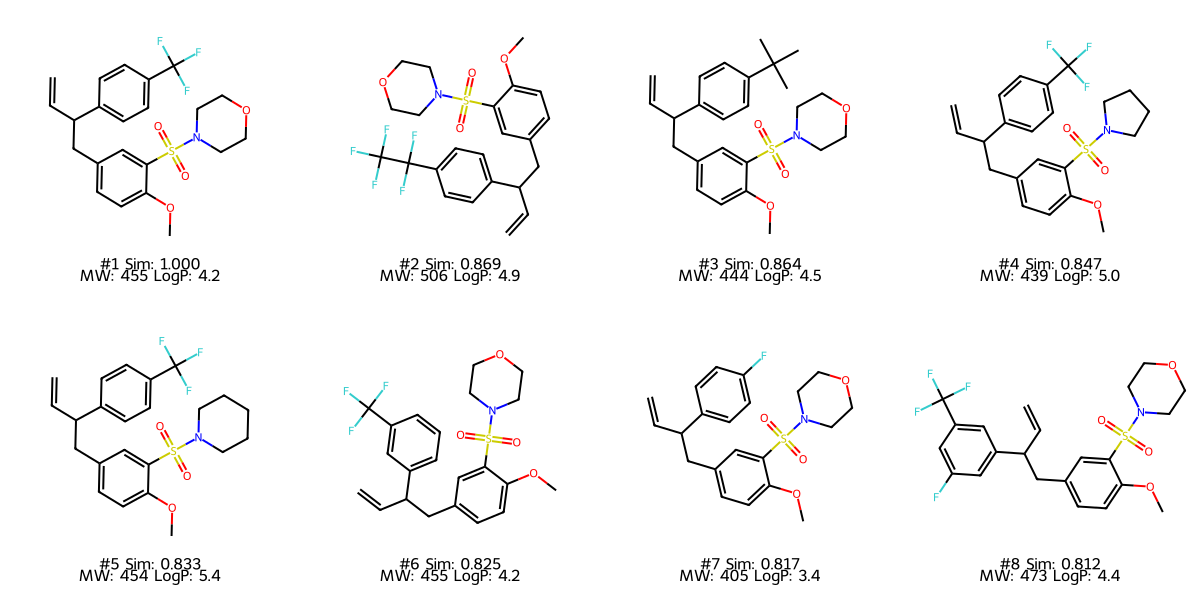

In [ ]:
# ============================================================================
# CELL 7: Visualize Top Molecules
# ============================================================================
#@title Visualize Top Molecules (Images)
#@markdown Show molecular structures

n_display = 8  #@param {type:"slider", min:4, max:24, step:4}

if len(results_df) > 0:
    top_mols = []
    top_legends = []

    for i, (idx, row) in enumerate(results_df.head(n_display).iterrows(), 1):
        mol = Chem.MolFromSmiles(row['Smiles'])
        if mol:
            top_mols.append(mol)
            legend = f"#{i} Sim: {row['product_similarity_to_hit']:.3f}\nMW: {row['MW']:.0f} LogP: {row['LogP']:.1f}"
            top_legends.append(legend)

    img = Draw.MolsToGridImage(top_mols, molsPerRow=4, subImgSize=(300, 300),
                               legends=top_legends, returnPNG=False)
    display(img)

In [ ]:
# ============================================================================
# CELL 8: Save and Download Results
# ============================================================================
#@title Save and Download Results

if len(results_df) > 0:
    # Save full results
    output_columns = ['Smiles', 'Code', 'MW', 'HAC', 'LogP', 'HBA', 'HBD',
                     'ROTB', 'FSP3', 'PSA', 'QED', 'Similarity_Distance']
    output_df = results_df[output_columns].copy()

    output_file = f'hit_expansion_{SELECTED_LAB}_{SELECTED_REACTION}_results.csv'
    output_df.to_csv(output_file, index=False)
    print(f"✓ Results saved to: {output_file}")

    # Download file
    from google.colab import files
    files.download(output_file)
    print(f"✓ File downloaded!")
else:
    print("No results to save!")

✓ Results saved to: hit_expansion_Lundgren_a5_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ File downloaded!
